# task 1 - Practice
- load a single spleen NIfTI volume,
- apply MONAI transforms
- visualize a slice with its label overlaid

In [1]:
# C:\DataSets\Medical_Segmentation_Decathlon\Task09_Spleen\Task09_Spleen

In [22]:
# Imports
from monai.utils import first, set_determinism
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    RandFlipd, 
    SaveImaged,
    ScaleIntensityRanged,
    Spacingd,
    Invertd,
)
from monai.handlers.utils import from_engine
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch
from monai.config import print_config
from monai.apps import download_and_extract
from flask import json
import torch
import matplotlib.pyplot as plt
import tempfile
import shutil
import os
import glob

print_config()

MONAI version: 1.5.2
Numpy version: 2.4.4
Pytorch version: 2.6.0+cu124
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: d:\Summer_Projects_2026\ct-segmentation-monai\summer_01_env\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.6
Nibabel version: 5.4.2
scikit-image version: 0.26.0
scipy version: 1.17.1
Pillow version: 12.2.0
Tensorboard version: 2.20.0
gdown version: 6.0.0
TorchVision version: 0.21.0+cu124
tqdm version: 4.67.3
lmdb version: 2.2.0
psutil version: 7.2.2
pandas version: 2.3.3
einops version: 0.8.2
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: 3.12.0
pynrrd version: 1.1.3
clearml version: 2.1.7

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



In [3]:
# Get the dataset directory
data_dir = "C:\\DataSets\\Medical_Segmentation_Decathlon\\Task09_Spleen\\Task09_Spleen"

if not os.path.exists(data_dir):
    #download_and_extract(resource, compressed_file, root_dir, md5)
    print("Error: Data file not found. Please download the dataset manually and place it in the specified directory.")

In [4]:
# load training data file paths and split into training and validation sets
train_images = sorted(glob.glob(os.path.join(data_dir, "imagesTr", "*.nii.gz")))
train_labels = sorted(glob.glob(os.path.join(data_dir, "labelsTr", "*.nii.gz")))
data_dicts = [{"image": image_name, "label": label_name} for image_name, label_name in zip(train_images, train_labels)]
train_files, val_files = data_dicts[:-9], data_dicts[-9:]

In [8]:
set_determinism(seed=1)

In [9]:
# Setup Transforms to augment the dataset

# Preprocessing for training data
train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]), # load the image and label from NlfTI files
        EnsureChannelFirstd(keys=["image", "label"]), # ensure channel first shape
        ScaleIntensityRanged( #normalize medical image intensites
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(keys=["image", "label"], source_key="image", allow_smaller=True), #crop medical images to remove unnecessary background and focus on the region of interest
        Orientationd(keys=["image", "label"], axcodes="RAS"), # standardizes orientation of images to a consistent coordinate system
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")), # resamples images to uniform voxel spacing
        RandCropByPosNegLabeld( # randomly crop sub-volumes from the image based on the presence of positive and negative labels, which helps to balance the training data and focus on relevant regions
            keys=["image", "label"],
            label_key="label",
            spatial_size=(96, 96, 96),
            pos=1,
            neg=1,
            num_samples=4,
            image_key="image",
            image_threshold=0,
        ),
    ]
)

# Preprocessing for validation data
val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=-57,
            a_max=164,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(keys=["image", "label"], source_key="image", allow_smaller=True),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    ]
)

image shape: torch.Size([228, 158, 113]), label shape: torch.Size([228, 158, 113])


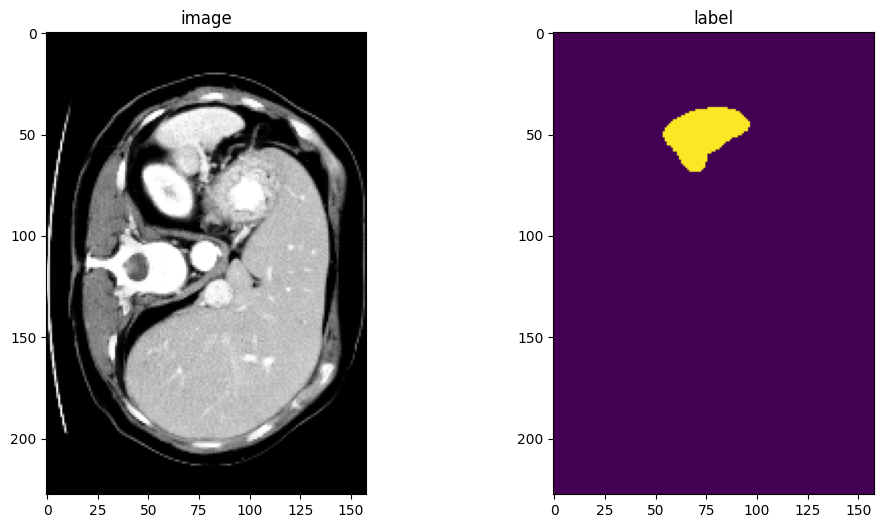

torch.Size([305, 267, 124]) torch.Size([305, 267, 124])


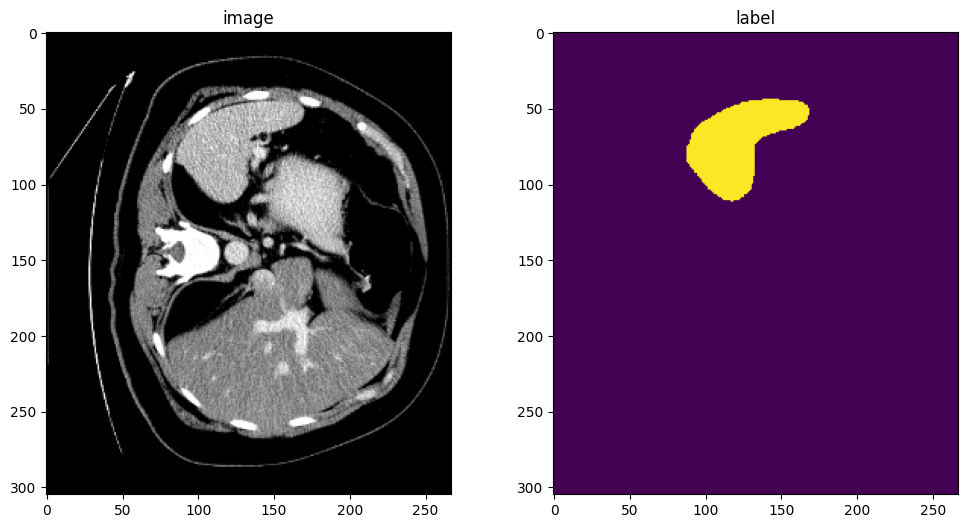

In [17]:
# check transforms in dataloader by presenting first image

check_ds = Dataset(data=val_files, transform=val_transforms) # create a dataset with the validation files and apply the validation transforms to it
check_loader = DataLoader(check_ds, batch_size=1) # create a dataloader to load the data in batches, batch size of 1 is used here to check the transforms on a single image
check_data = first(check_loader)
image, label = (check_data["image"][0][0], check_data["label"][0][0])

print(f"image shape: {image.shape}, label shape: {label.shape}")
# plot the slice [:, :, 80]
plt.figure("check", (12, 6))
plt.subplot(1, 2, 1)
plt.title("image")
plt.imshow(image[:, :, 80], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("label")
plt.imshow(label[:, :, 80])
plt.show()


for i, batch in enumerate(check_loader):
    if i == 1:
        image = batch["image"][0][0]
        label = batch["label"][0][0]
        print(image.shape, label.shape)
        
        plt.figure("check", (12, 6))
        plt.subplot(1, 2, 1)
        plt.title("image")
        plt.imshow(image[:, :, 80], cmap="gray")
        plt.subplot(1, 2, 2)
        plt.title("label")
        plt.imshow(label[:, :, 80])
        plt.show()
        
        break
    else:
        continue


# Task 2 -  Building the full transform Pipeline + DataLoader
1. Seperate Train and validation transforms
2. Train/Val split from dataset.json
3. DataLoader for both

In [20]:

# Preprocessing for training data (Task 2)
train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0)),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
        RandCropByPosNegLabeld(keys=["image", "label"], label_key="label", spatial_size=(96,96,96)),
        RandFlipd(keys=["image", "label"], prob=0.5),
    ]
)

# Preprocessing for validation data (task 2)
val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0)),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
    ]
)

In [ ]:
# Train/Validation split (Task 2) from dataset.json
# Take the training data defined in the json file and split it into training and validation sets using an 80/20 split.
# We still have the test data defined in the json file but we are keeping that seperate for final evaluation.
with open(os.path.join(data_dir, "dataset.json")) as f:
    datalist = json.load(f)["training"]
# 80/20 split
train_files = datalist[:int(len(datalist)*0.8)]
val_files = datalist[int(len(datalist)*0.8):]